In [ ]:
!pip install imbalanced-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

SCENARIO 1 – BAGGING

In [ ]:
from sklearn.datasets import load_diabetes

# Using sklearn dataset (replace with CSV if needed)
data = load_diabetes()
X = pd.DataFrame(data.data)
y = (data.target > data.target.mean()).astype(int)  # Convert to classification

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

In [ ]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)
bag_acc = accuracy_score(y_test, y_pred_bag)

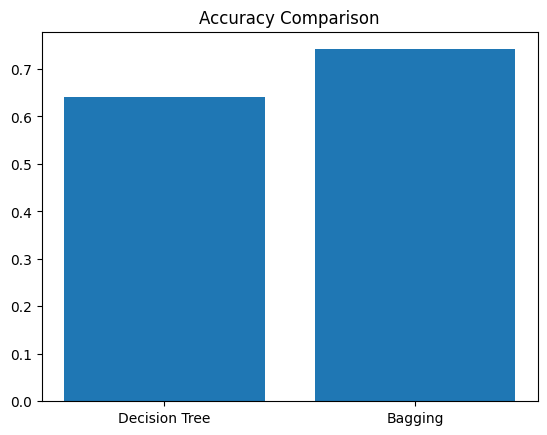

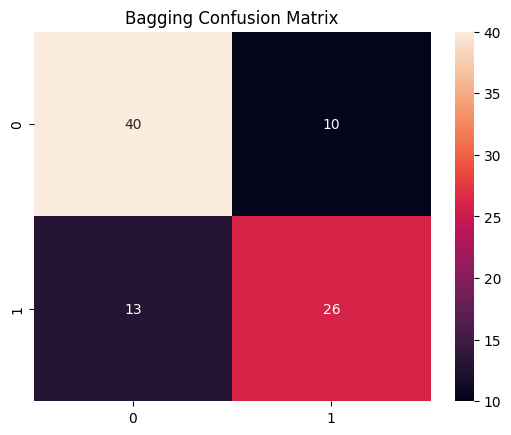

In [ ]:
# Accuracy Comparison
plt.bar(['Decision Tree', 'Bagging'], [dt_acc, bag_acc])
plt.title("Accuracy Comparison")
plt.show()

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True, fmt='d')
plt.title("Bagging Confusion Matrix")
plt.show()

SCENARIO 2 – BOOSTING

In [ ]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=2000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

In [ ]:
gb = GradientBoostingClassifier(n_estimators=50)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

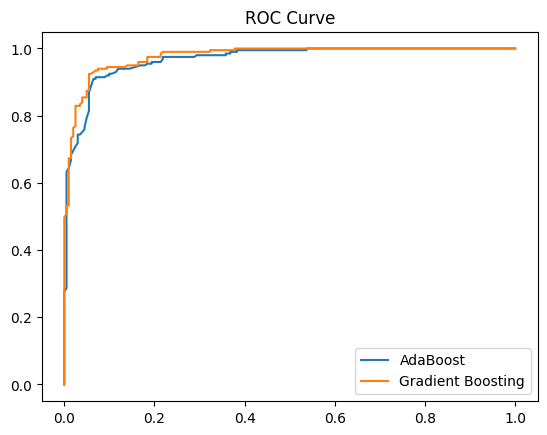

In [ ]:
fpr1, tpr1, _ = roc_curve(y_test, ada.predict_proba(X_test)[:,1])
fpr2, tpr2, _ = roc_curve(y_test, gb.predict_proba(X_test)[:,1])

plt.plot(fpr1, tpr1, label="AdaBoost")
plt.plot(fpr2, tpr2, label="Gradient Boosting")
plt.legend()
plt.title("ROC Curve")
plt.show()

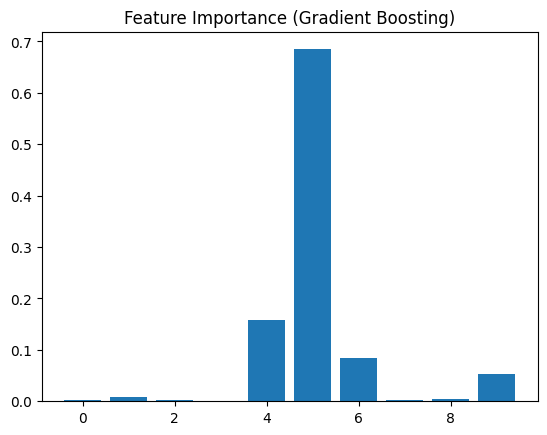

In [ ]:
plt.bar(range(len(gb.feature_importances_)), gb.feature_importances_)
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

SCENARIO 3 – RANDOM FOREST

In [ ]:
X, y = make_classification(n_samples=2000, n_features=8, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
trees = [10, 50, 100, 150]
acc = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    acc.append(accuracy_score(y_test, rf.predict(X_test)))

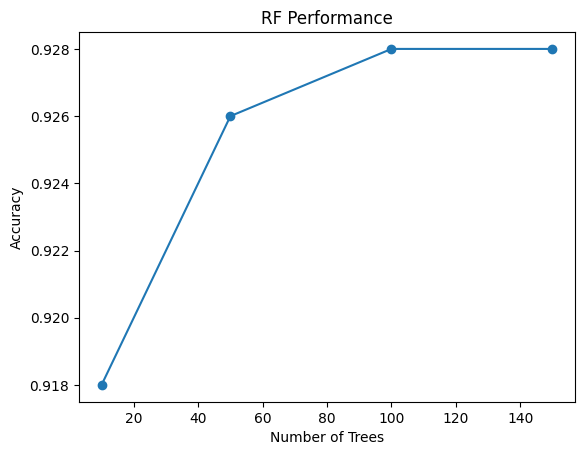

In [ ]:
plt.plot(trees, acc, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("RF Performance")
plt.show()

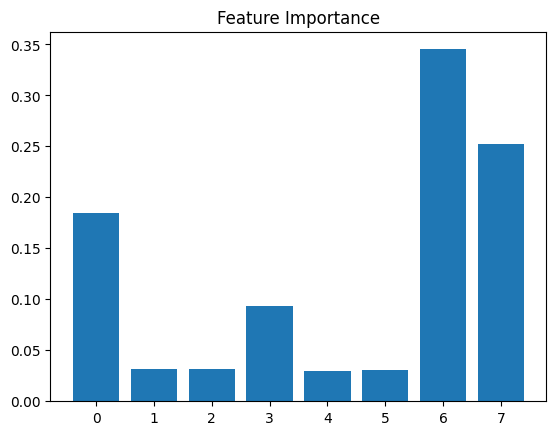

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.bar(range(len(rf.feature_importances_)), rf.feature_importances_)
plt.title("Feature Importance")
plt.show()

SCENARIO 4 – STACKING

In [ ]:
X, y = make_classification(n_samples=1500, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

In [ ]:
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)

stack_acc = accuracy_score(y_test, stack.predict(X_test))

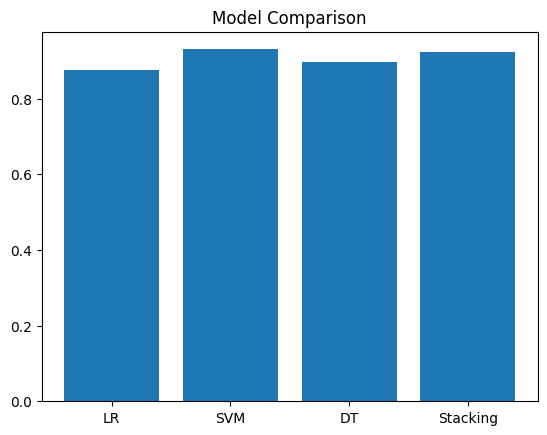

In [ ]:
lr = LogisticRegression().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)

accs = [
    accuracy_score(y_test, lr.predict(X_test)),
    accuracy_score(y_test, svm.predict(X_test)),
    accuracy_score(y_test, dt.predict(X_test)),
    stack_acc
]

labels = ['LR', 'SVM', 'DT', 'Stacking']

plt.bar(labels, accs)
plt.title("Model Comparison")
plt.show()

SCENARIO 5 – SMOTE

In [ ]:
X, y = make_classification(n_samples=2000, weights=[0.95, 0.05], random_state=42)

print("Before SMOTE:", np.bincount(y))

Before SMOTE: [1893  107]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Before SMOTE Report:\n", classification_report(y_test, y_pred))

Before SMOTE Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       466
           1       0.74      0.50      0.60        34

    accuracy                           0.95       500
   macro avg       0.85      0.74      0.79       500
weighted avg       0.95      0.95      0.95       500



In [ ]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_res))

After SMOTE: [1427 1427]


In [ ]:
model.fit(X_res, y_res)
y_pred_smote = model.predict(X_test)

print("After SMOTE Report:\n", classification_report(y_test, y_pred_smote))

After SMOTE Report:
               precision    recall  f1-score   support

           0       0.99      0.88      0.93       466
           1       0.36      0.91      0.52        34

    accuracy                           0.88       500
   macro avg       0.68      0.90      0.73       500
weighted avg       0.95      0.88      0.91       500



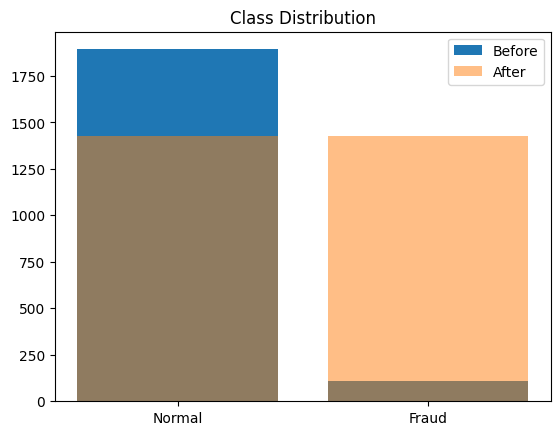

In [ ]:
# Class Distribution
plt.bar(['Normal','Fraud'], np.bincount(y), label='Before')
plt.bar(['Normal','Fraud'], np.bincount(y_res), alpha=0.5, label='After')
plt.legend()
plt.title("Class Distribution")
plt.show()

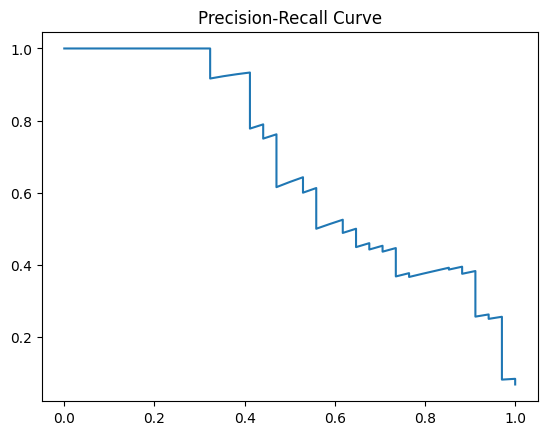

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()